In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from collections import defaultdict
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [78]:
df = pd.read_csv("./datasets/mackey_glass.csv")
print(f"Data loaded. Total length: {len(df)}")

split_ratio = 0.8
split_idx = int(split_ratio * len(df))

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()

train_values = train_df["value"].values  
test_values  = test_df['value'].values

print(f"Train: {len(train_df)} samples  ({split_ratio*100:.0f}%)")
print(f"Test: {len(test_df)} samples   ({(1-split_ratio)*100:.0f}%)")

Data loaded. Total length: 1000
Train: 800 samples  (80%)
Test: 200 samples   (20%)


In [79]:
y_min = train_df["value"].min()
y_max = train_df["value"].max()
D = 0.2 * (y_max - y_min)
U_min = y_min - D
U_max = y_max + D

print(f"U_min: {U_min:.4f}    U_max: {U_max:.4f}")

U_min: -0.2609    U_max: 1.8168


In [80]:
series_train = train_df["value"].values
n = len(series_train)
tau = 17
m = 3

N = n - (m - 1) * tau
X = np.zeros((N, m))
for i in range(m):
    X[:, i] = series_train[i*tau : i*tau + N]

print(f"Phase space shape (train): {X.shape}")

Phase space shape (train): (766, 3)


In [82]:
c_selected = 29
print(f"\nSelected number of clusters: {c_selected}")

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X.T, c=c_selected, m=2.0, error=0.005, maxiter=1000
)

centers = np.sort(cntr[:, 0])
print("Sorted centers:", centers)


Selected number of clusters: 29
Sorted centers: [0.11861774 0.17176501 0.26437315 0.32228312 0.32976486 0.37490877
 0.39680646 0.44150691 0.54450019 0.55437758 0.55726587 0.59846184
 0.6056566  0.69661762 0.7212458  0.76749291 0.87858101 0.92608564
 0.9288591  0.93963268 1.03490986 1.096517   1.11046113 1.17594693
 1.20253365 1.31268896 1.3664517  1.37500219 1.41868597]


In [83]:
boundaries = [(centers[i] + centers[i+1])/2 for i in range(len(centers)-1)]



intervals = [(U_min, boundaries[0])]
for i in range(len(boundaries)-1):
    intervals.append((boundaries[i], boundaries[i+1]))
intervals.append((boundaries[-1], U_max))

fuzzy_sets = []
for i in range(len(centers)):
    if i == 0:
        a, b, c = intervals[0][0], centers[0], centers[1]
    elif i == len(centers)-1:
        a, b, c = centers[-2], centers[-1], intervals[-1][1]
    else:
        a, b, c = centers[i-1], centers[i], centers[i+1]
    fuzzy_sets.append((a, b, c))

print("\nFuzzy sets (triangular):")
for i, (a,b,c) in enumerate(fuzzy_sets, 1):
    print(f"A{i}:  {a:>8.4f} → {b:>8.4f} → {c:>8.4f}")


Fuzzy sets (triangular):
A1:   -0.2609 →   0.1186 →   0.1718
A2:    0.1186 →   0.1718 →   0.2644
A3:    0.1718 →   0.2644 →   0.3223
A4:    0.2644 →   0.3223 →   0.3298
A5:    0.3223 →   0.3298 →   0.3749
A6:    0.3298 →   0.3749 →   0.3968
A7:    0.3749 →   0.3968 →   0.4415
A8:    0.3968 →   0.4415 →   0.5445
A9:    0.4415 →   0.5445 →   0.5544
A10:    0.5445 →   0.5544 →   0.5573
A11:    0.5544 →   0.5573 →   0.5985
A12:    0.5573 →   0.5985 →   0.6057
A13:    0.5985 →   0.6057 →   0.6966
A14:    0.6057 →   0.6966 →   0.7212
A15:    0.6966 →   0.7212 →   0.7675
A16:    0.7212 →   0.7675 →   0.8786
A17:    0.7675 →   0.8786 →   0.9261
A18:    0.8786 →   0.9261 →   0.9289
A19:    0.9261 →   0.9289 →   0.9396
A20:    0.9289 →   0.9396 →   1.0349
A21:    0.9396 →   1.0349 →   1.0965
A22:    1.0349 →   1.0965 →   1.1105
A23:    1.0965 →   1.1105 →   1.1759
A24:    1.1105 →   1.1759 →   1.2025
A25:    1.1759 →   1.2025 →   1.3127
A26:    1.2025 →   1.3127 →   1.3665
A27:    1.3127 →   1.

In [84]:
def triangular_mf(x, a, b, c):
    if x <= a or x >= c:
        return 0.0
    if x <= b:
        return (x - a) / (b - a) if b != a else 0.0
    return (c - x) / (c - b) if c != b else 0.0

def fuzzify(value, fuzzy_sets):
    mfs = [triangular_mf(value, *fs) for fs in fuzzy_sets]
    return np.argmax(mfs)

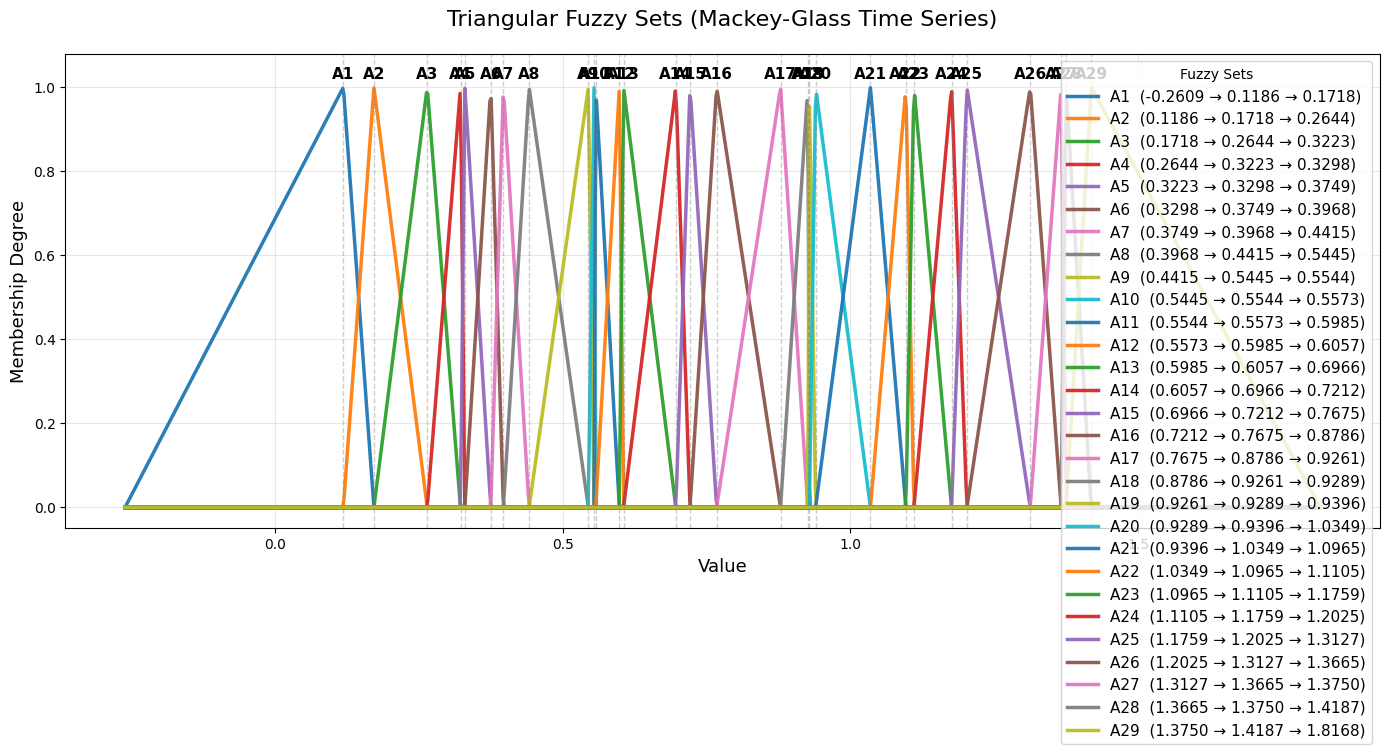

In [85]:
# =============================================================================
# VISUALIZATION OF TRIANGULAR FUZZY SETS
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt

# x range over the whole universe of discourse
x = np.linspace(U_min, U_max, 1000)

plt.figure(figsize=(14, 7))

for i, (a, b, c) in enumerate(fuzzy_sets, 1):
    # Compute membership for every point
    y = [triangular_mf(val, a, b, c) for val in x]
    
    plt.plot(x, y, 
             label=f'A{i}  ({a:.4f} → {b:.4f} → {c:.4f})',
             linewidth=2.5,
             alpha=0.95)

# Add vertical lines at the centers (the peaks)
for i, (a, b, c) in enumerate(fuzzy_sets, 1):
    plt.axvline(x=b, color='gray', linestyle='--', alpha=0.4, linewidth=1)
    plt.text(b, 1.02, f'A{i}', ha='center', fontsize=11, fontweight='bold')

plt.title('Triangular Fuzzy Sets (Mackey-Glass Time Series)', fontsize=16, pad=20)
plt.xlabel('Value', fontsize=13)
plt.ylabel('Membership Degree', fontsize=13)
plt.legend(title='Fuzzy Sets', fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim(-0.05, 1.08)
plt.tight_layout()
plt.show()

In [86]:
all_values = df["value"].values
labels = np.array([fuzzify(v, fuzzy_sets) for v in all_values])

print("\nUnique labels:", np.unique(labels))
print("First 15 labels:", labels[:15])


Unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28]
First 15 labels: [8 7 6 5 4 3 2 2 1 1 1 1 0 0 0]


In [87]:
def which_partition(value, fuzzy_sets):

    memberships = []
    
    for a, b, c in fuzzy_sets:
        if value <= a or value >= c:
            mu = 0.0
        elif value <= b:
            mu = (value - a) / (b - a) if b != a else 0.0
        else:
            mu = (c - value) / (c - b) if c != b else 0.0
        memberships.append(mu)
    
    if max(memberships) == 0:
    
        return None 
    
    return np.argmax(memberships)



In [88]:

train_partitions = []
for val in train_values:
    idx = which_partition(val, fuzzy_sets)
    if idx is None:
        train_partitions.append(-1)  
    else:
        train_partitions.append(idx)

train_partitions = np.array(train_partitions)
unique_parts, counts = np.unique(train_partitions, return_counts=True)


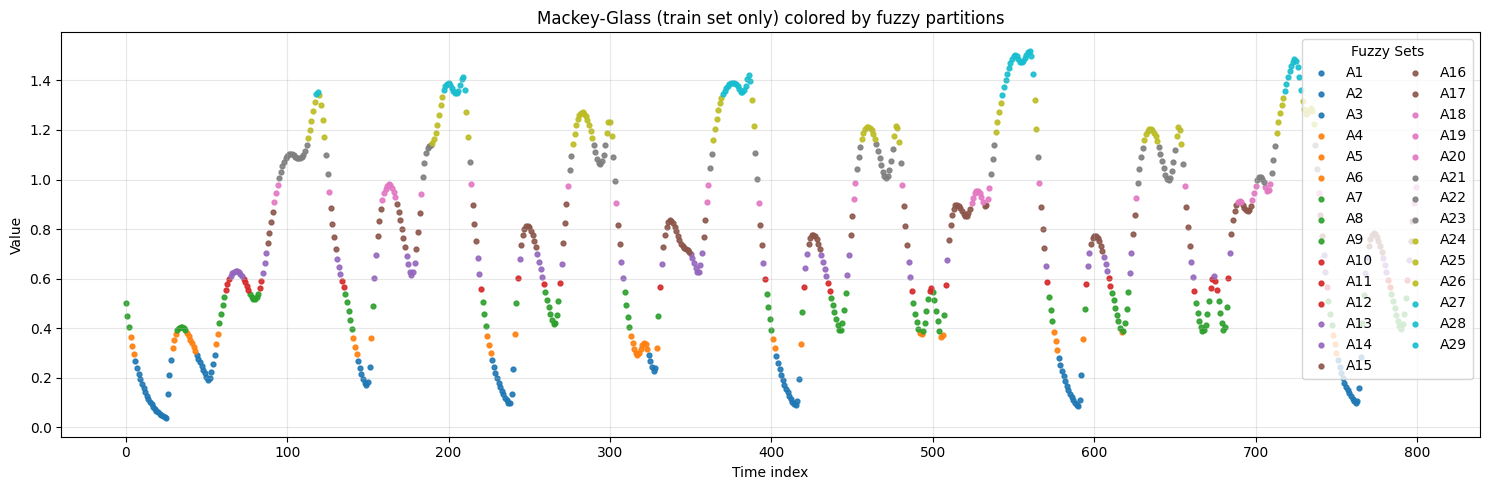

In [89]:
n_clusters = len(fuzzy_sets)
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

train_values = train_df["value"].values               
train_labels = labels[:len(train_df)]                
train_indices = np.arange(len(train_df))              

plt.figure(figsize=(15, 5))

for lbl in range(n_clusters):
    mask = (train_labels == lbl)
    plt.scatter(
        train_indices[mask],
        train_values[mask],
        color=colors[lbl],
        s=12,
        label=f"A{lbl+1}",
        alpha=0.9
    )

plt.title("Mackey-Glass (train set only) colored by fuzzy partitions")
plt.xlabel("Time index")
plt.ylabel("Value")
plt.legend(title="Fuzzy Sets", loc='upper right', ncol=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [90]:


n_clusters = len(centers)
labels_train = labels[:len(train_df)]   


flrg = defaultdict(lambda: defaultdict(int))

for t in range(len(labels_train) - 1):
    current = labels_train[t]
    next_one = labels_train[t+1]
    flrg[current][next_one] += 1

print("FLRG (First-Order, Weighted):")
for lhs in sorted(flrg.keys()):
    rhs_parts = []
    for rhs, count in flrg[lhs].items():
        rhs_parts.append(f"A{rhs+1}({count})")
    print(f"A{lhs+1} → {', '.join(rhs_parts)}")

FLRG (First-Order, Weighted):
A1 → A1(36), A2(4), A3(1)
A2 → A2(22), A1(5), A3(4), A5(1), A6(1)
A3 → A3(20), A2(7), A4(2), A5(1), A6(2), A8(1)
A4 → A3(8), A6(1), A4(6), A5(1), A8(1)
A5 → A4(7), A6(1), A5(2), A8(1)
A6 → A5(6), A6(5), A7(3), A8(4), A4(2), A9(1)
A7 → A6(10), A7(13), A8(7)
A8 → A7(14), A8(21), A9(8), A13(1), A11(4), A6(1), A12(1)
A9 → A8(15), A9(11), A10(2), A11(2), A12(3), A13(3)
A10 → A12(1), A9(5), A11(1)
A11 → A10(1), A12(2), A9(7), A14(2), A13(2)
A12 → A12(2), A13(3), A11(4), A14(4), A9(2), A10(2)
A13 → A13(14), A12(7), A14(9), A11(3), A9(1), A10(2)
A14 → A14(9), A15(8), A13(12), A16(7), A12(1)
A15 → A16(7), A14(11), A17(1), A15(8), A13(1)
A16 → A17(10), A16(28), A15(12), A14(2)
A17 → A17(27), A18(10), A16(8), A20(2)
A18 → A20(8), A16(2), A18(3), A17(2), A21(1)
A19 → A17(1), A18(1)
A20 → A20(14), A21(8), A17(6), A19(2)
A21 → A21(17), A22(10), A20(4), A18(2), A23(1)
A22 → A22(12), A23(10), A21(5), A20(3), A24(1)
A23 → A22(4), A23(7), A24(9), A21(2), A25(1)
A24 → A25(10

In [96]:
order = 2

flrg_ho = defaultdict(lambda: defaultdict(int))

for t in range(order, len(labels_train)):
    lhs = tuple(labels_train[t-order : t])   
    rhs = labels_train[t]
    flrg_ho[lhs][rhs] += 1  

print(f"FLRG (High-Order Weighted, order={order}):")
print("-" * 50)

for lhs_tuple in sorted(flrg_ho.keys()):
    lhs_str = " → ".join(f"A{i+1}" for i in lhs_tuple)
    
    rhs_parts = []
    for rhs, count in flrg_ho[lhs_tuple].items():
        rhs_parts.append(f"A{rhs+1}({count})")
    
    print(f"{lhs_str}  →  {', '.join(rhs_parts)}")



FLRG (High-Order Weighted, order=2):
--------------------------------------------------
A1 → A1  →  A1(31), A2(4), A3(1)
A1 → A2  →  A3(2), A5(1), A6(1)
A1 → A3  →  A6(1)
A2 → A1  →  A1(5)
A2 → A2  →  A2(15), A1(5), A3(2)
A2 → A3  →  A4(1), A3(1), A6(1), A8(1)
A2 → A5  →  A8(1)
A2 → A6  →  A8(1)
A3 → A2  →  A2(7)
A3 → A3  →  A2(7), A3(11), A5(1), A4(1)
A3 → A4  →  A6(1), A8(1)
A3 → A5  →  A6(1)
A3 → A6  →  A8(1), A9(1)
A3 → A8  →  A9(1)
A4 → A3  →  A3(8)
A4 → A4  →  A3(2), A4(3), A5(1)
A4 → A5  →  A5(1)
A4 → A6  →  A6(1)
A4 → A8  →  A11(1)
A5 → A4  →  A3(5), A4(2)
A5 → A5  →  A5(1), A4(1)
A5 → A6  →  A8(1)
A5 → A8  →  A11(1)
A6 → A4  →  A4(1), A3(1)
A6 → A5  →  A4(6)
A6 → A6  →  A7(2), A6(1), A5(1), A8(1)
A6 → A7  →  A7(1), A8(2)
A6 → A8  →  A8(1), A13(1), A11(2)
A6 → A9  →  A12(1)
A7 → A6  →  A5(4), A6(3), A4(2), A7(1)
A7 → A7  →  A7(8), A6(1), A8(4)
A7 → A8  →  A8(4), A9(2), A12(1)
A8 → A6  →  A5(1)
A8 → A7  →  A6(9), A8(1), A7(4)
A8 → A8  →  A9(5), A7(11), A8(4), A6(1)
A8 → A9  →  A

In [ ]:
def centroid_of_fuzzy_sets(rhs_dict, centers):
    if not rhs_dict:
        return np.nan

    numerator = 0.0
    denominator = 0.0

    for idx, weight in rhs_dict.items():
        numerator += centers[idx] * weight
        denominator += weight

    return numerator / denominator


def predict_fofts(current_idx, flrg, centers):
    if current_idx not in flrg or not flrg[current_idx]:
        return centers[current_idx]
    return centroid_of_fuzzy_sets(flrg[current_idx], centers)


def predict_hofts(prev_seq, flrg_ho, centers, order):
    key = tuple(prev_seq)
    if key not in flrg_ho or not flrg_ho[key]:
        return centers[prev_seq[-1]]
    return centroid_of_fuzzy_sets(flrg_ho[key], centers)

In [98]:
def evaluate_model_on_data(
    values,          
    start_labels,     
    flrg, flrg_ho, centers, order=2,
    model_type='both'
):
    if len(values) < 2:
        return None, None, None

    actual = values[1:]        
    preds_fofts = []
    preds_hofts = []

    if model_type in ['fofts', 'both']:
        current = start_labels[-1]  
        for _ in range(len(values)-1):
            pred = predict_fofts(current, flrg, centers)
            preds_fofts.append(pred)
            current = which_partition(pred, fuzzy_sets)  

    if model_type in ['hofts', 'both']:
        current_seq = list(start_labels[-order:])   
        for _ in range(len(values)-1):
            pred = predict_hofts(current_seq, flrg_ho, centers, order)
            preds_hofts.append(pred)
            next_p = which_partition(pred, fuzzy_sets)
            current_seq = current_seq[1:] + [next_p]

    results = {}
    if preds_fofts:
        preds_fofts = np.array(preds_fofts)
        mse  = np.mean((actual - preds_fofts)**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_fofts))
        results['fofts'] = (mse, rmse, mae)

    if preds_hofts:
        preds_hofts = np.array(preds_hofts)
        mse  = np.mean((actual - preds_hofts)**2)
        rmse = np.sqrt(mse)
        mae  = np.mean(np.abs(actual - preds_hofts))
        results['hofts'] = (mse, rmse, mae)

    return results

In [ ]:
def get_predictions(model_type='hofts', order=2):
    
    test_labels = labels[len(train_df):]

    
    if model_type == 'fofts':
        preds = []

        for t in range(len(test_values) - 1):
            current_label = test_labels[t]          
            pred = predict_fofts(current_label, flrg, centers)
            preds.append(pred)

        return np.array(preds)


    else:
        preds = []

       
        for t in range(order, len(test_values)):
            seq = test_labels[t-order:t]      
            pred = predict_hofts(seq, flrg_ho, centers, order)
            preds.append(pred)

        return np.array(preds)



pred_fofts = get_predictions('fofts')
pred_hofts = get_predictions('hofts')

actual_test_fofts = test_values[1:]
actual_test_hofts = test_values[order:]

def compute_metrics(y_true, y_pred, name="Model"):
    mse  = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2   = r2_score(y_true, y_pred)

    accuracy = 100 - mape
    
    print(f"\n{name}")
    print(f"   MSE  = {mse:8.6f}")
    print(f"   RMSE = {rmse:8.4f}")
    print(f"   MAE  = {mae:8.4f}")
    print(f"   MAPE = {mape:8.3f} %")
    print(f"   R²   = {r2:8.4f}")
    print(f"   Accuracy = {accuracy:8.3f} %")

    return mse, rmse, mae, mape, r2, accuracy



print("═"*60)
print("          TEST SET ACCURACY METRICS")
print("═"*60)

metrics_fofts = compute_metrics(actual_test_fofts, pred_fofts, "FOFTS (one-step)")
metrics_hofts = compute_metrics(actual_test_hofts, pred_hofts, "HOFTS (one-step)")

best = "HOFTS" if metrics_hofts[0] < metrics_fofts[0] else "FOFTS"
print("\n" + "─"*60)
print(f"🏆 Best model on Test set → {best}")
print("─"*60)

════════════════════════════════════════════════════════════
          TEST SET ACCURACY METRICS
════════════════════════════════════════════════════════════

FOFTS (one-step)
   MSE  = 0.003767
   RMSE =   0.0614
   MAE  =   0.0466
   MAPE =    7.148 %
   R²   =   0.9747
   Accuracy =   92.852 %

HOFTS (one-step)
   MSE  = 0.002899
   RMSE =   0.0538
   MAE  =   0.0375
   MAPE =    5.625 %
   R²   =   0.9806
   Accuracy =   94.375 %

────────────────────────────────────────────────────────────
🏆 Best model on Test set → HOFTS
────────────────────────────────────────────────────────────


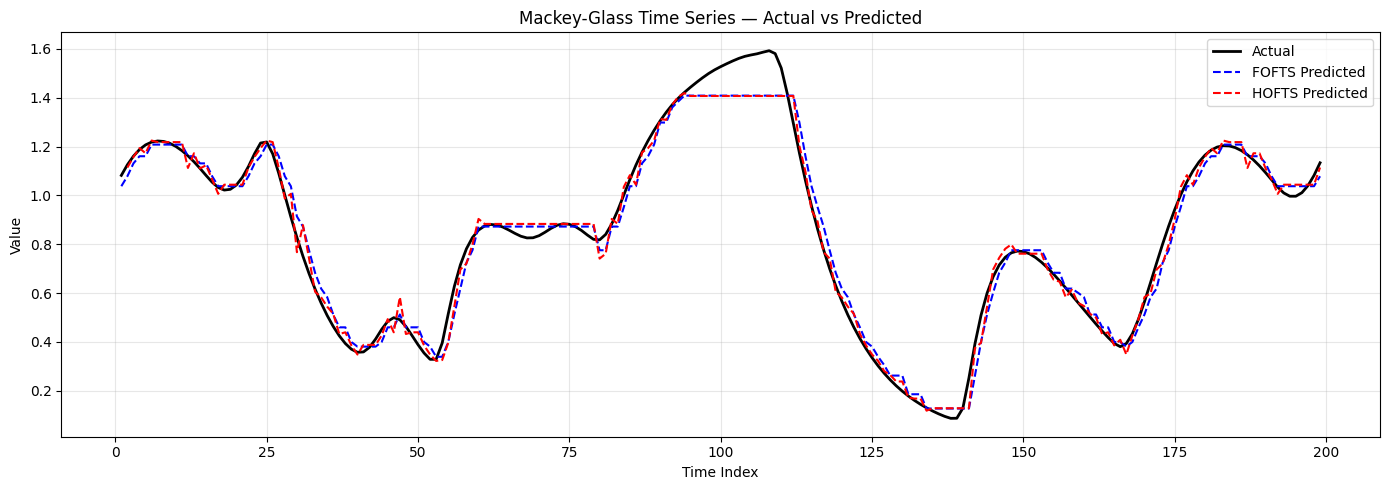

In [ ]:
def plot_actual_vs_pred_mg(test_values, pred_fofts, pred_hofts, order=2):
    import matplotlib.pyplot as plt
    import numpy as np

    time_fofts = np.arange(1, len(test_values))
    time_hofts = np.arange(order, len(test_values))

    plt.figure(figsize=(14,5))
    plt.plot(time_fofts, test_values[1:], label='Actual', color='black', linewidth=2)
    plt.plot(time_fofts, pred_fofts, label='FOFTS Predicted', color='blue', linestyle='--')
    plt.plot(time_hofts, pred_hofts, label='HOFTS Predicted', color='red', linestyle='--')
    plt.title("Mackey-Glass Time Series — Actual vs Predicted")
    plt.xlabel("Time Index")
    plt.ylabel("Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_actual_vs_pred_mg(test_values, pred_fofts, pred_hofts, order=order)
